In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Users/hp333/Desktop/Recommander_system/data/final_dataset.csv")

In [2]:
df.columns

Index(['id', 'title', 'year', 'duration', 'MPA', 'rating', 'votes',
       'meta_score', 'description', 'Movie_Link', 'writers', 'directors',
       'stars', 'budget', 'opening_weekend_gross', 'gross_worldwide',
       'gross_us_canada', 'release_date', 'countries_origin',
       'filming_locations', 'production_companies', 'awards_content', 'genres',
       'languages'],
      dtype='object')

In [3]:
movies = df[['id', 'title', 'year', 'description', 'writers', 'directors', 'stars', 'countries_origin', 'production_companies', 'genres', 'languages']].copy()
movies.head()

,id,title,year,description,writers,directors,stars,countries_origin,production_companies,genres,languages
0,tt0073195,Jaws,1975,When a massive killer shark unleashes chaos on...,"['Peter Benchley', 'Carl Gottlieb']",['Steven Spielberg'],"['Roy Scheider', 'Robert Shaw', 'Richard Dreyf...",['United States'],"['Zanuck/Brown Productions', 'Universal Pictur...","['Monster Horror', 'Sea Adventure', 'Survival'...",['English']
1,tt0073629,The Rocky Horror Picture Show,1975,A newly-engaged couple have a breakdown in an ...,"[""Richard O'Brien"", 'Jim Sharman']",['Jim Sharman'],"['Tim Curry', 'Susan Sarandon', 'Barry Bostwic...","['United Kingdom', 'United States']","['Twentieth Century Fox', 'Michael White Produ...","['B-Horror', 'Dark Comedy', 'Parody', 'Raunchy...",['English']
2,tt0073486,One Flew Over the Cuckoo's Nest,1975,"In the Fall of 1963, a Korean War veteran and ...","['Lawrence Hauben', 'Bo Goldman', 'Ken Kesey']",['Milos Forman'],"['Jack Nicholson', 'Louise Fletcher', 'Michael...",['United States'],"['Fantasy Films', 'N.V. Zvaluw']","['Medical Drama', 'Psychological Drama', 'Drama']",['English']
3,tt0072890,Dog Day Afternoon,1975,Three amateur robbers plan to hold up a Brookl...,"['Frank Pierson', 'P.F. Kluge', 'Thomas Moore']",['Sidney Lumet'],"['Al Pacino', 'John Cazale', 'Penelope Allen',...",['United States'],"['Warner Bros.', 'Artists Entertainment Complex']","['Dark Comedy', 'Heist', 'True Crime', 'Biogra...",['English']
4,tt0073692,Shampoo,1975,"On Election Day, 1968, irresponsible hairdress...","['Robert Towne', 'Warren Beatty']",['Hal Ashby'],"['Warren Beatty', 'Julie Christie', 'Goldie Ha...",['United States'],"['Persky-Bright / Vista', 'Columbia Pictures',...","['Satire', 'Comedy', 'Drama']",['English']


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63249 entries, 0 to 63248
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    63249 non-null  object
 1   title                 63249 non-null  object
 2   year                  63249 non-null  int64 
 3   description           60889 non-null  object
 4   writers               62980 non-null  object
 5   directors             63198 non-null  object
 6   stars                 62905 non-null  object
 7   countries_origin      63150 non-null  object
 8   production_companies  61276 non-null  object
 9   genres                62462 non-null  object
 10  languages             62919 non-null  object
dtypes: int64(1), object(10)
memory usage: 5.3+ MB


In [5]:
movies.isnull().sum()

id                         0
title                      0
year                       0
description             2360
writers                  269
directors                 51
stars                    344
countries_origin          99
production_companies    1973
genres                   787
languages                330
dtype: int64

In [6]:
movies.fillna(
    {  
        'description' : 'NotAvailable',
        'writers': 'NoKnown',
        'directors': 'NotKnown',
        'stars': 'NotKnown',
        'countries_origin' : 'NotKnown',
        'production_companies': 'NotKnown',
        'languages' : 'NotKnown'
    },inplace = True
)
movies.dropna(subset=['genres'], inplace=True)
movies.isnull().sum()

id                      0
title                   0
year                    0
description             0
writers                 0
directors               0
stars                   0
countries_origin        0
production_companies    0
genres                  0
languages               0
dtype: int64

In [7]:
def safe_eval(x):
    if isinstance(x, str):  # only try to parse strings
        try:
            return ast.literal_eval(x)
        except Exception:
            return []  # fallback if parsing fails
    elif isinstance(x, list):  # already a list
        return x
    else:
        return []  # for NaN or other types

movies['production_companies'] = movies['production_companies'].apply(safe_eval)
movies['writers'] = movies['writers'].apply(safe_eval)
movies['directors'] = movies['directors'].apply(safe_eval)
movies['stars'] = movies['stars'].apply(safe_eval)
movies['countries_origin'] = movies['countries_origin'].apply(safe_eval)
movies['languages'] = movies['languages'].apply(safe_eval)
movies['genres'] = movies['genres'].apply(safe_eval)

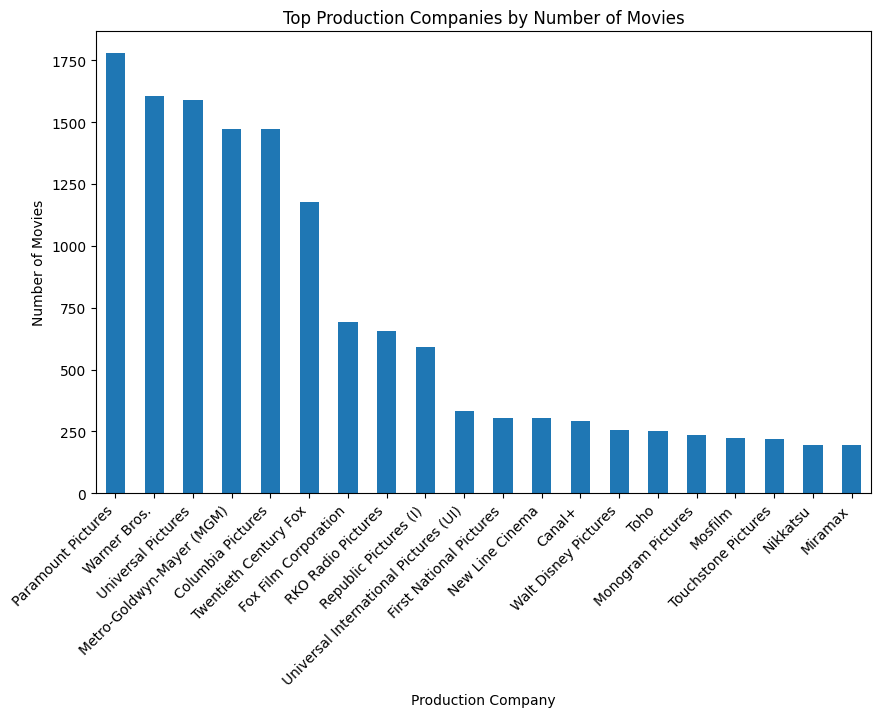

In [8]:
all_companies = [company for sublist in movies['production_companies'] for company in sublist]

company_counts = pd.Series(all_companies).value_counts()

company_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top Production Companies by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

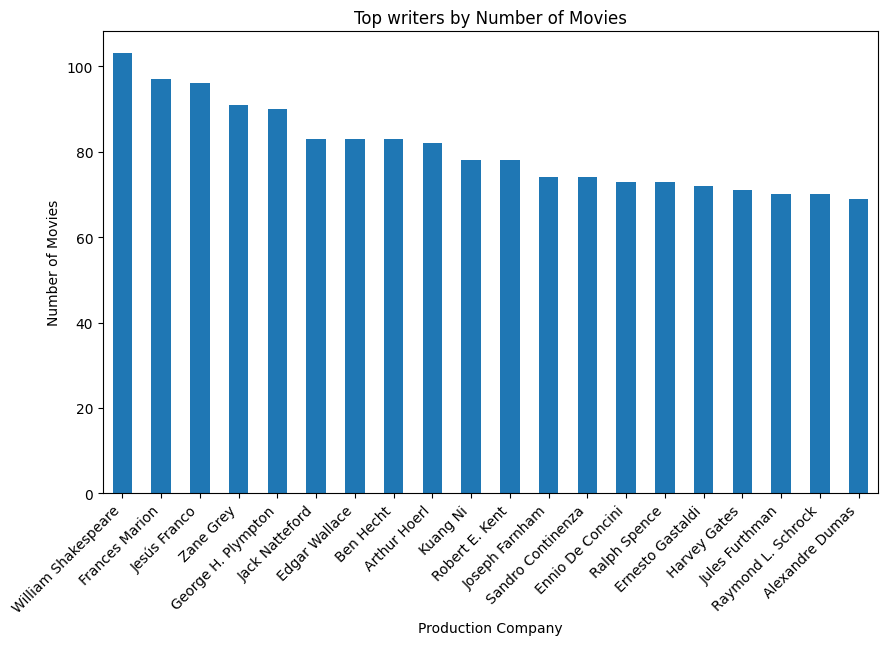

In [9]:
all_writers = [writer for sublist in movies['writers'] for writer in sublist]

writer_counts = pd.Series(all_writers).value_counts()

writer_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top writers by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

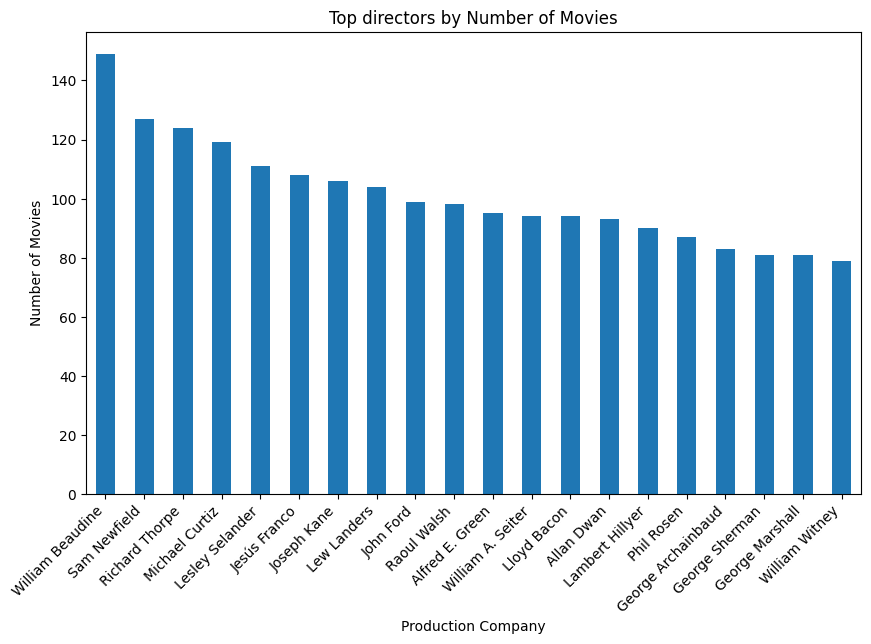

In [10]:
all_directors = [director for sublist in movies['directors'] for director in sublist]

director_counts = pd.Series(all_directors).value_counts()

director_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top directors by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

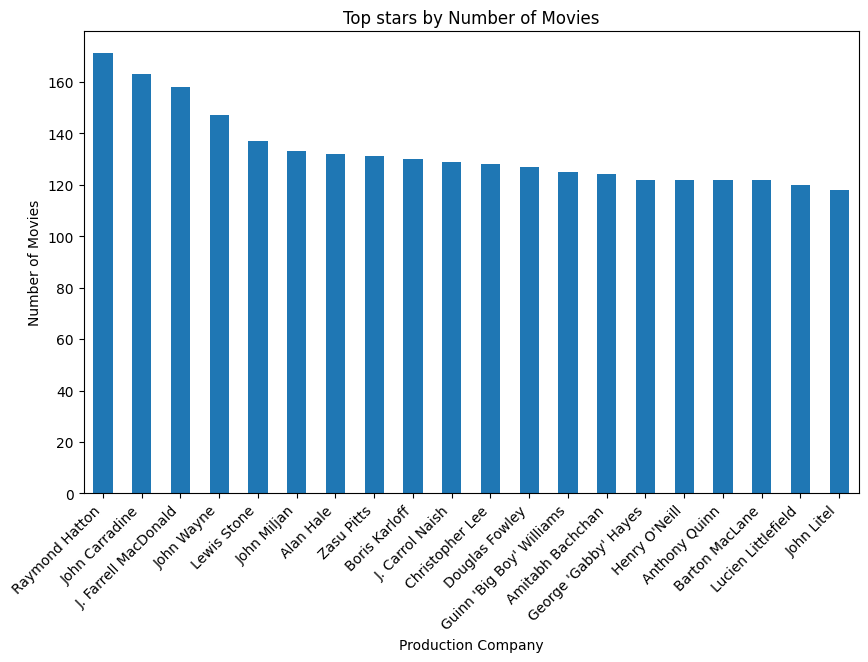

In [11]:
all_stars = [star for sublist in movies['stars'] for star in sublist]

star_counts = pd.Series(all_stars).value_counts()

star_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top stars by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

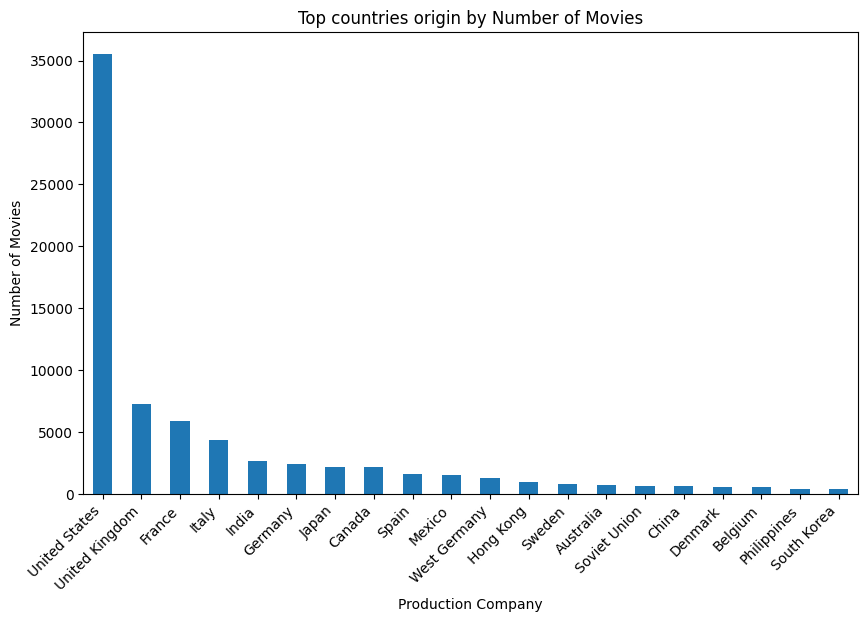

In [12]:
all_countries = [countury for sublist in movies['countries_origin'] for countury in sublist]

countury_counts = pd.Series(all_countries).value_counts()

countury_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top countries origin by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

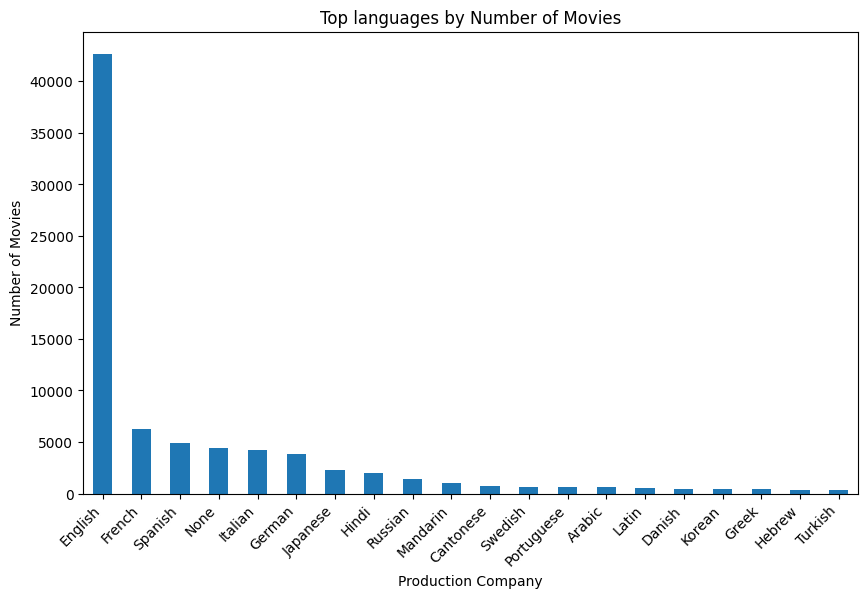

In [13]:
all_languages = [language for sublist in movies['languages'] for language in sublist]

language_counts = pd.Series(all_languages).value_counts()

language_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top languages by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

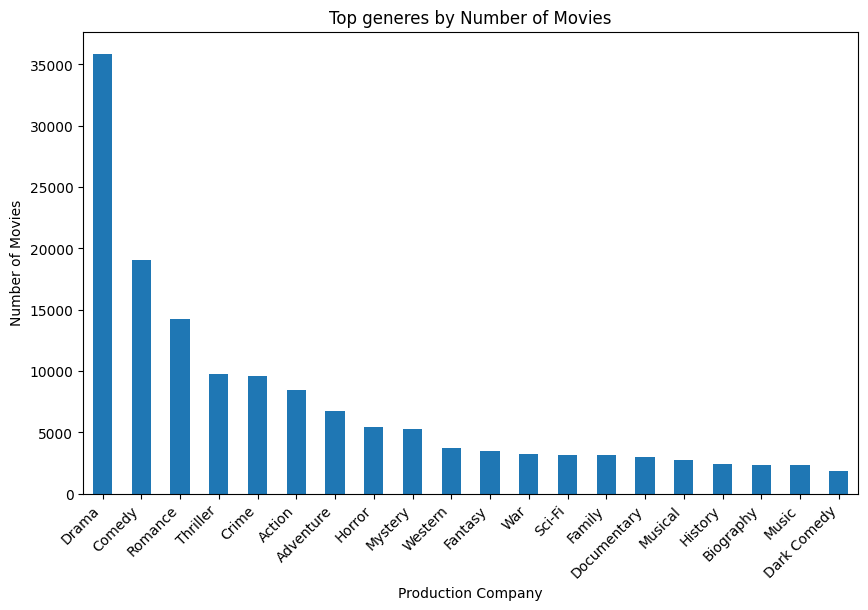

In [14]:
all_genres = [gneres for sublist in movies['genres'] for gneres in sublist]

generes_counts = pd.Series(all_genres).value_counts()

generes_counts.head(20).plot(kind="bar", figsize=(10,6))
plt.title("Top generes by Number of Movies")
plt.ylabel("Number of Movies")
plt.xlabel("Production Company")
plt.xticks(rotation=45, ha="right")
plt.show()

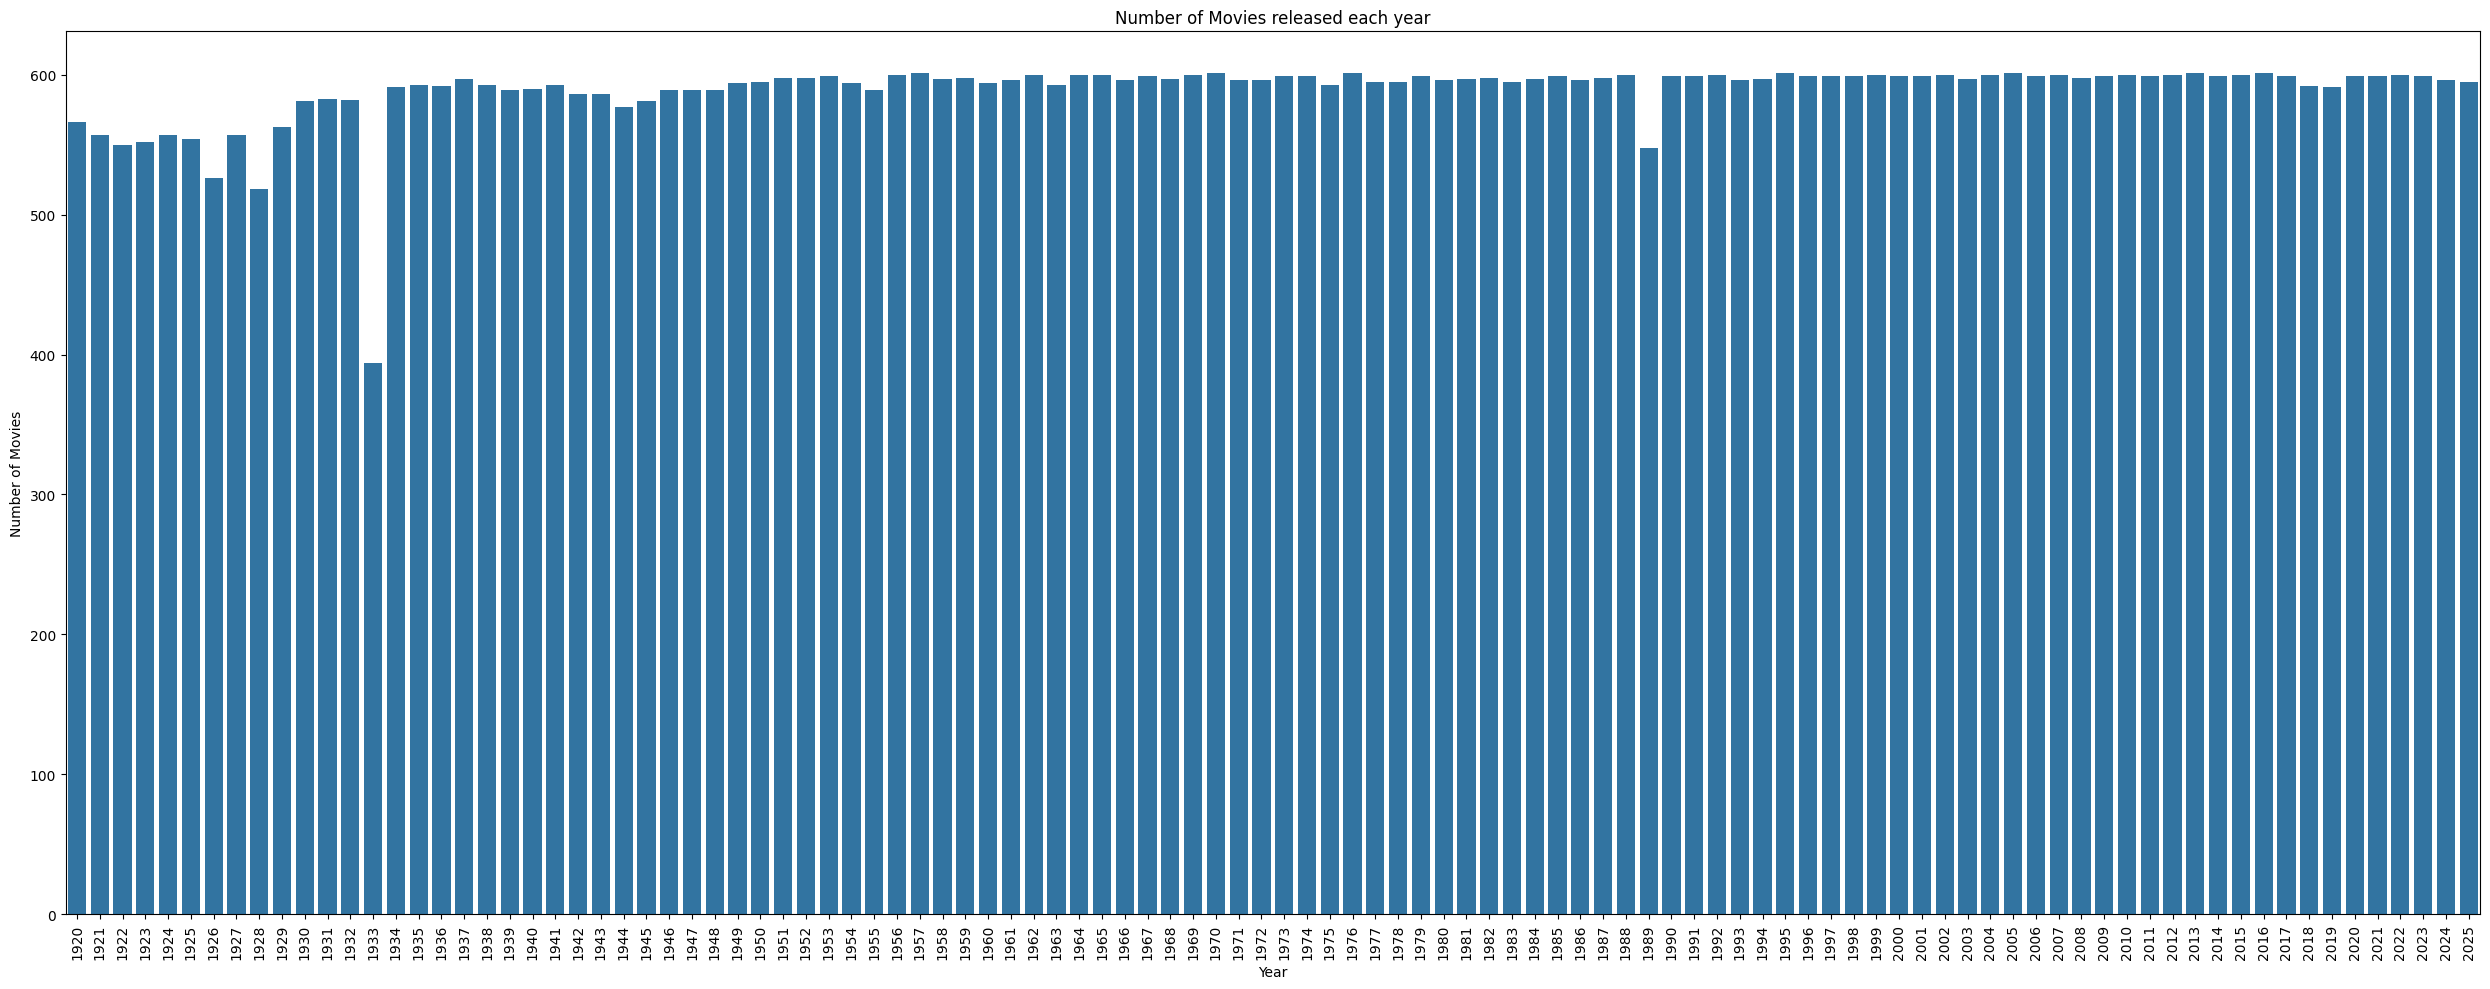

In [15]:
plt.figure(figsize = (25, 10))
plt.title('Number of Movies released each year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
sns.countplot(x = movies['year'], data = movies)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [16]:
movies = movies.reset_index(drop = True)

In [17]:
movies.columns

Index(['id', 'title', 'year', 'description', 'writers', 'directors', 'stars',
       'countries_origin', 'production_companies', 'genres', 'languages'],
      dtype='object')

In [18]:
movies['directors'] = movies['directors'].apply(lambda x: [name.replace(" ", "") for name in x])
movies['writers'] = movies['writers'].apply(lambda x: [name.replace(" ", "") for name in x])
movies['stars'] = movies['stars'].apply(lambda x: [name.replace(" ", "") for name in x])
movies['countries_origin'] = movies['countries_origin'].apply(lambda x: [name.replace(" ", "") for name in x])
movies['production_companies'] = movies['production_companies'].apply(lambda x: [name.replace(" ", "") for name in x])

In [19]:
movies['cast'] = movies[['writers','directors', 'stars']].apply(lambda x: ' '.join(map(str, x)), axis=1)

In [20]:
movies['description'] = movies['description'].astype(str)
movies['cast'] = movies['cast'].astype(str)
movies['countries_origin'] = movies['countries_origin'].astype(str)
movies['production_companies'] = movies['production_companies'].astype(str)
movies['genres'] = movies['genres'].astype(str)
movies['languages'] = movies['languages'].astype(str)

movies['mix'] = movies[['description','cast', 'countries_origin', 'production_companies', 'genres', 'languages']].apply(lambda x: ' '.join(map(str, x)), axis=1)

In [24]:
movies.columns

Index(['id', 'title', 'year', 'description', 'writers', 'directors', 'stars',
       'countries_origin', 'production_companies', 'genres', 'languages',
       'cast', 'mix'],
      dtype='object')

In [23]:
movies.to_csv("movies_dataset.csv", index = False)